# LuminaFlux
***Bit depth expansion using signal processing techniques***




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
import pandas as pd
from src.visualization import visualize_bde_results
from src.image_generator import combine_primary_gradients, apply_s_curve_contrast_numpy
import torch
from skimage.metrics import peak_signal_noise_ratio as psnr_func
from skimage.metrics import structural_similarity as ssim_func # type: ignore[reportArgumentType]
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity # type: ignore[reportArgumentType]
# Enable inline static plots
%matplotlib inline

print("Libraries imported successfully.")


Libraries imported successfully.


## Metrics for Evaluation

In order to evaluate the performance of diffrent bit depth expansion techniques we can use metrics besides visual inspection. These include:

- **Peak Signal-to-Noise Ratio (PSNR)**: Measures the ratio between the maximum possible power of a signal and the power of corrupting noise. Higher PSNR indicates better quality.
- **Structural Similarity Index (SSIM)**: Measures the similarity between two images. It considers changes in structural information, luminance, and contrast. Higher SSIM indicates better quality.
- **lpips**: A perceptual similarity metric that uses deep learning to evaluate the similarity between two images. Lower lpips indicates better quality.


In [ ]:
def compute_psnr(pred: np.ndarray, target: np.ndarray) -> float:
    return float(psnr_func(target, pred, data_range=1.0))


def compute_ssim(pred: np.ndarray, target: np.ndarray) -> float:

    # skimage expects [H, W, C]
    pred_hwc = np.transpose(pred, (1, 2, 0))
    target_hwc = np.transpose(target, (1, 2, 0))
    return float(ssim_func(target, pred, channel_axis=0, data_range=1.0))  # type: ignore[reportArgumentType]


def compute_lpips(pred: np.ndarray, target: np.ndarray) -> float:
    """
    Compute LPIPS distance between two [C, H, W] float32 images.
    Lower is better (0.0 means identical).
    """
    lpips_metric = LearnedPerceptualImagePatchSimilarity(
        net_type="vgg", normalize=True
    )

    # Clamp to [0, 1] and convert to float tensors of shape [1, C, H, W]
    pred_t = torch.from_numpy(np.clip(pred, 0.0, 1.0)).unsqueeze(0).float()
    target_t = torch.from_numpy(np.clip(target, 0.0, 1.0)).unsqueeze(0).float()

    with torch.no_grad():
        score = lpips_metric(pred_t, target_t)
    return float(score.item())

# dataframe visualisation

metrics_df = pd.DataFrame(columns=["image", "method", "psnr", "ssim", "lpips"])
metrics_df = metrics_df.round({"psnr": 2, "ssim": 5, "lpips": 4})

def add_metrics(image_name: str, method: str, pred: np.ndarray, target: np.ndarray) -> pd.DataFrame:
    """
    Adds a new row of metrics to the provided DataFrame and displays it.
    """
    psnr = compute_psnr(pred, target)
    ssim = compute_ssim(pred, target)
    lpips = compute_lpips(pred, target)

    # Adding the row at the next available index
    metrics_df.loc[len(metrics_df)] = [image_name, method, psnr, ssim, lpips]    

    return metrics_df

## generate test gradient

In order to test the bit depth expansion, in a controlled way, we can generate a test gradient. this is done using the a gradient generator, made for LuminaScale (my semester project).

In [ ]:
# 1. Generate 32-bit Reference Gradient (Smooth)
grad_32f = combine_primary_gradients(width=512, height=64, dtype="float32")

# 2. Simulate 8-bit Quantization (NumPy only)
# Round to 255 levels and scale back to [0, 1]
grad_8u = np.round(grad_32f * 255.0).astype(np.float32) / 255.0

# 3. Visualize the results
metrics_df = add_metrics("gradient", "input 8-bit", grad_8u, grad_32f)
display(metrics_df)


,image,method,psnr,ssim,lpips
0,gradient,input 8-bit,60.714603,0.999224,0.002879


Input shape: (3, 579, 512)
Output shape: (3, 579, 512)


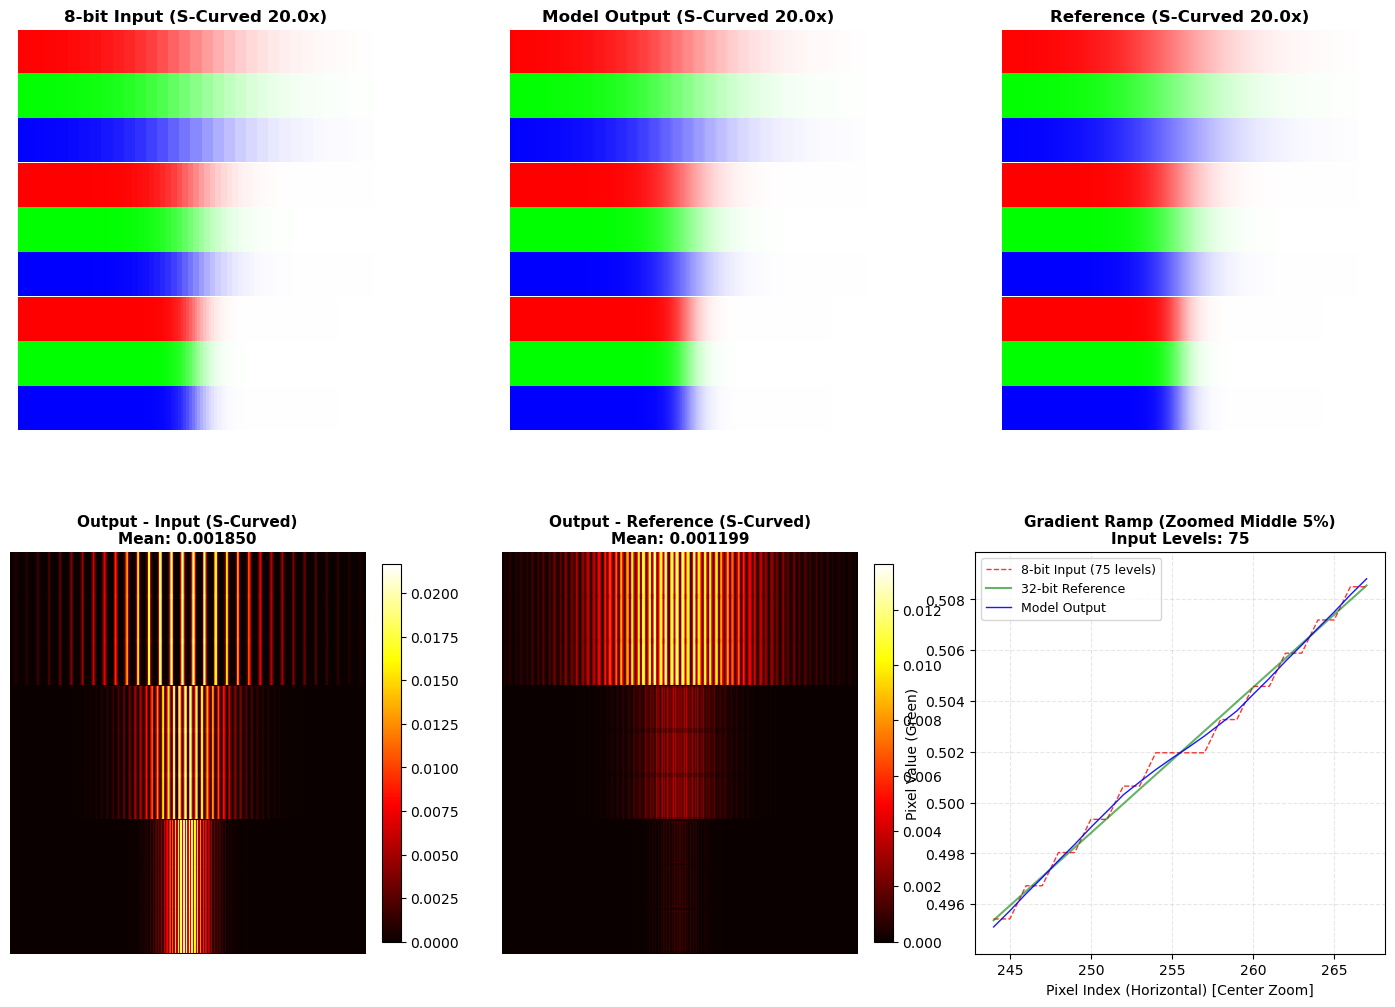

,image,method,psnr,ssim,lpips
0,gradient,input 8-bit,60.714603,0.999224,0.002879
1,gradient,bilateral,68.840677,0.999940,0.000108


In [4]:
# Bilateral Filter Implementation


def apply_bilateral_bde(img: np.ndarray, d: int = 5, sigma_color: float = 0.1, sigma_space: float = 5.0) -> np.ndarray:
    """
    Parameters
    src	Source 8-bit or floating-point, 1-channel or 3-channel image.
    d	Diameter of each pixel neighborhood that is used during filtering. If it is non-positive, it is computed from sigmaSpace.
    sigmaColor	Filter sigma in the color space. A larger value of the parameter means that farther colors within the pixel neighborhood (see sigmaSpace) will be mixed together, resulting in larger areas of semi-equal color.
    sigmaSpace	Filter sigma in the coordinate space. A larger value of the parameter means that farther pixels will influence each other as long as their colors are close enough (see sigmaColor ). When d>0, it specifies the neighborhood size regardless of sigmaSpace. Otherwise, d is proportional to sigmaSpace.
    """
    img_hwc = np.transpose(img, (1, 2, 0))
    denoised_hwc = cv2.bilateralFilter(img_hwc, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    return np.transpose(denoised_hwc, (2, 0, 1))


grad_bilateral_output = apply_bilateral_bde(grad_8u, d=9, sigma_color=0.05, sigma_space=30.0)

# Check shape before visualizing
print(f"Input shape: {grad_8u.shape}")
print(f"Output shape: {grad_bilateral_output.shape}")

# 2. Visualize using our helper with abstracted strength
visualize_bde_results(grad_8u, grad_bilateral_output, grad_32f, strength=20.0)

metrics_df = add_metrics("gradient", "bilateral", grad_bilateral_output, grad_32f)
display(metrics_df)

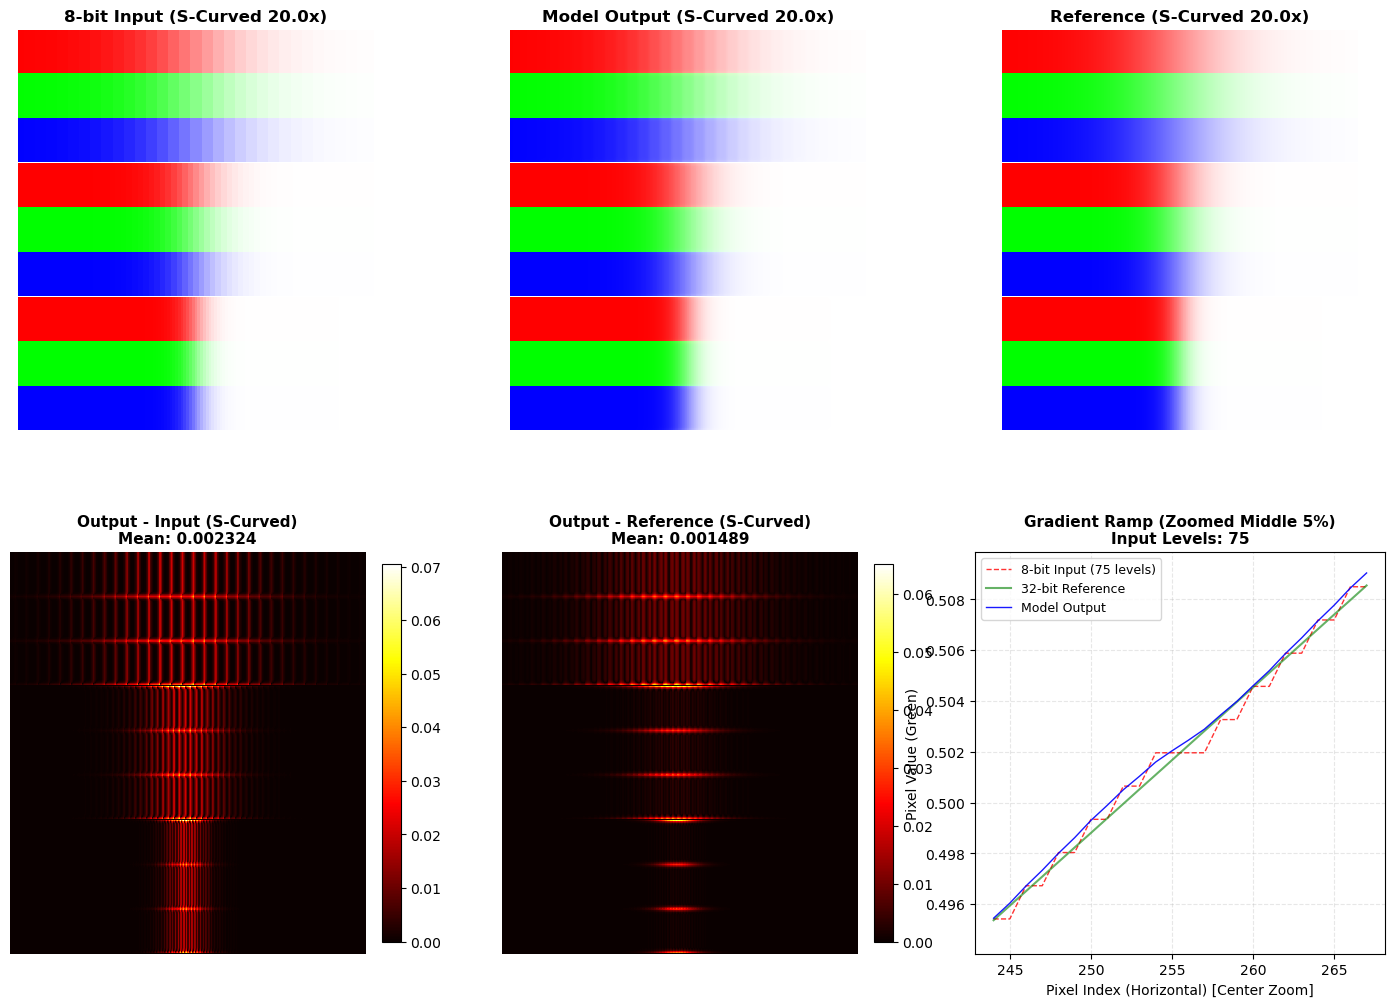

,image,method,psnr,ssim,lpips
0,gradient,input 8-bit,60.714603,0.999224,0.002879
1,gradient,bilateral,68.840677,0.999940,0.000108
2,gradient,tv denoising,59.127414,0.999873,0.000155


In [6]:
from skimage.restoration import denoise_tv_chambolle

# Total Variation (TV) Denoising Implementation
# TV denoising is an optimization approach that minimizes the total variation of the image.
# It is excellent at removing small noise while preserving sharp edges.

def apply_tv_bde(img: np.ndarray, weight: float = 0.1) -> np.ndarray:
    """
    Apply Total Variation (TV) denoising to a [3, H, W] float32 image.
    In scikit-image, weight controls the trade-off between smoothing and data fidelity.
    Higher weight = more smoothing.
    """
    # scikit-image expects [H, W, 3] for multi-channel TV denoising
    img_hwc = np.transpose(img, (1, 2, 0))
    
    # Apply TV Chambolle denoising
    denoised_hwc = denoise_tv_chambolle(img_hwc, weight=weight, channel_axis=-1)
    
    return np.transpose(denoised_hwc, (2, 0, 1))

# 1. Run the TV denoising on our 8-bit quantized simulation
# We use a relatively high weight to aggressively smooth the staircase artifacts
grad_tv_output = apply_tv_bde(grad_8u, weight=0.01)
# 2. Visualize using our helper (strength=20.0 for comparison with Bilateral)
visualize_bde_results(grad_8u, grad_tv_output, grad_32f, strength=20.0, 
                       titles=["INPUT (8-bit)", "OUTPUT (TV Denoising)", "TARGET (32-bit Ref)"])

metrics_df = add_metrics("gradient", "tv denoising", grad_tv_output, grad_32f)
display(metrics_df)

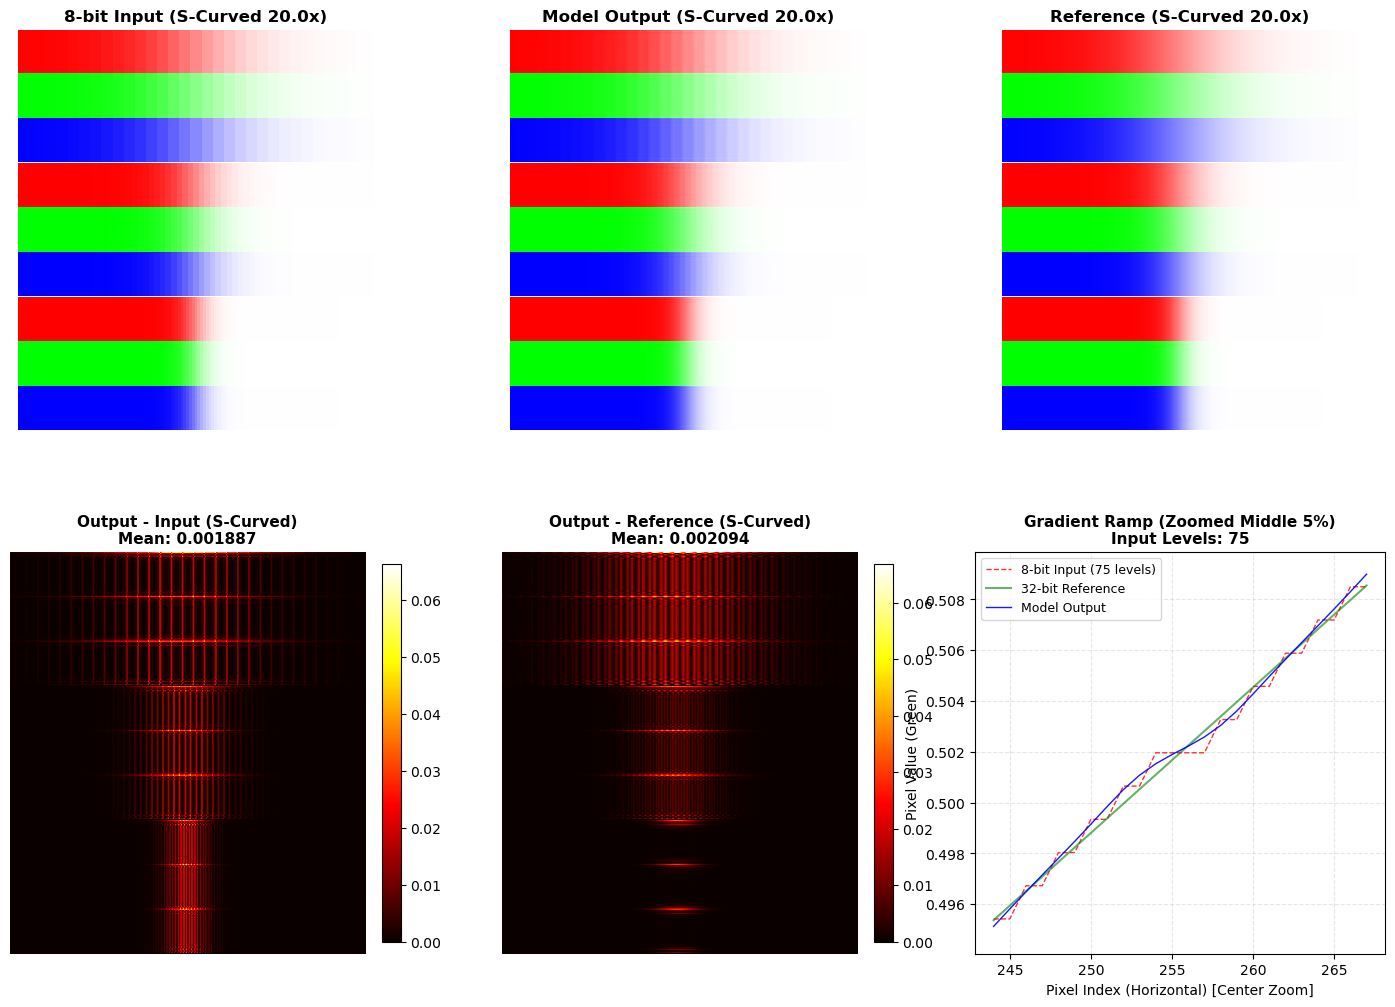

,image,method,psnr,ssim,lpips
0,gradient,input 8-bit,60.714603,0.999224,0.002879
1,gradient,bilateral,68.840677,0.999940,0.000108
2,gradient,tv denoising,59.127414,0.999873,0.000155
3,gradient,swt denoising,61.222356,0.999741,0.000399


In [7]:
import pywt

# Stationary Wavelet Transform (SWT) BDE Implementation
# Unlike the Discrete Wavelet Transform (DWT), SWT is translation-invariant 
# (no downsampling), which is critical for image restoration to avoid aliasing.

def apply_swt_bde(img: np.ndarray, wavelet: str = 'db2', level: int = 2, threshold: float = 0.01) -> np.ndarray:
    """
    Apply SWT-based denoising to a [3, H, W] float32 image.
    Uses soft-thresholding on high-frequency coefficients to smooth quantization steps.
    """
    # SWT requires dimensions to be divisible by 2^level
    c, h, w = img.shape
    pad_h = (2**level - h % 2**level) % 2**level
    pad_w = (2**level - w % 2**level) % 2**level
    
    img_padded = np.pad(img, ((0,0), (0, pad_h), (0, pad_w)), mode='reflect')
    
    denoised_channels = []
    for ch in range(c):
        # Perform SWT: returns list of (cA_n, (cH_n, cV_n, cD_n), ..., (cH_1, cV_1, cD_1))
        coeffs = pywt.swt2(img_padded[ch], wavelet, level)
        
        new_coeffs = []
        for i, (cA, (cH, cV, cD)) in enumerate(coeffs):
            # Soft-threshold high-frequency components
            # Quantization 'steps' manifest as high-frequency noise
            cH_t = pywt.threshold(cH, threshold, mode='soft')
            cV_t = pywt.threshold(cV, threshold, mode='soft')
            cD_t = pywt.threshold(cD, threshold, mode='soft')
            new_coeffs.append((cA, (cH_t, cV_t, cD_t)))
            
        # Inverse SWT
        denoised_ch = pywt.iswt2(new_coeffs, wavelet)
        denoised_channels.append(denoised_ch)
    
    output = np.stack(denoised_channels)
    
    # Remove padding
    return np.clip(output[:, :h, :w], 0, 1)

# 1. Run the SWT BDE
grad_swt_output = apply_swt_bde(grad_8u, wavelet='db4', level=2, threshold=0.005)

# 2. Visualize using our helper
visualize_bde_results(grad_8u, grad_swt_output, grad_32f, strength=20.0,
                       titles=["INPUT (8-bit)", "OUTPUT (SWT Denoising)", "TARGET (32-bit Ref)", "DIFFERENCE (x10)"])

metrics_df = add_metrics("gradient", "swt denoising", grad_swt_output, grad_32f)
display(metrics_df)